In [1]:
import voltaiq_studio as vs
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# For each test, set either TR_NAME_FILTER (partial/full name match) or TR_ID
# (numeric ID). If TR_ID is not None it takes priority over the name filter.

TEST_CONFIGS = [
    {
        "label":          "Veken_HT-B_15C",
        "TR_NAME_FILTER": "CV_0010_CS2D7009_Pr_RPT_15C",
        "TR_ID":          None,
        "color":          "#1f77b4",   # Blue
        "linestyle":      "-",
    },
    
    {
        "label":          "Veken_HT-B_20C",
        "TR_NAME_FILTER": "CV_0010_CS2D7009_Pr_RPT_20C",
        "TR_ID":          None,
        "color":          "#4da9ff",   # Blue
        "linestyle":      "-",
    },
    
    
    {
        "label":          "Veken_HT-B_25C",
        "TR_NAME_FILTER": "CV_0010_CS2D7009_Pr_RPT_25C",
        "TR_ID":          None,
        "color":          "#008000",   # Red
        "linestyle":      "-",
    }]
 

In [3]:
CYCLE_TO_PLOT = 6

X_LIM      = (155, 175)   # Charge capacity axis range (Ah) — adjust as needed
Y_LIM      = (3.1, 3.5) # Voltage axis range (V)

FIG_WIDTH  = 12
FIG_HEIGHT = 7

#OUTPUT_FILENAME = "ColdTChar_Char_VvsCap_ABs_zoomed_cyc6_v1.png"

In [4]:
def find_test_record(tr_name_filter, tr_id):
    if tr_id is not None:
        tr = vs.get_test_record(tr_id)
        if tr is None:
            raise ValueError(f"No test record found with ID: {tr_id}")
        print(f"✔  Loaded by ID [{tr.id}]: {tr.name}")
        return tr

    all_trs = vs.get_test_records()
    matches = [t for t in all_trs if tr_name_filter.lower() in t.name.lower()]

    if not matches:
        raise ValueError(f"No test records found matching: '{tr_name_filter}'")
    if len(matches) > 1:
        print(f"⚠  Found {len(matches)} records matching '{tr_name_filter}'. Using the first:")
        for t in matches:
            print(f"   [{t.id}] {t.name}")
    tr = matches[0]
    print(f"✔  Loaded [{tr.id}]: {tr.name}")
    return tr

print("Helper defined.")

Helper defined.


In [5]:
test_records = []
for cfg in TEST_CONFIGS:
    tr = find_test_record(cfg["TR_NAME_FILTER"], cfg["TR_ID"])
    test_records.append(tr)

print(f"\n✔  {len(test_records)} test records loaded.")

✔  Loaded [3999]: CV_0010_CS2D7009_Pr_RPT_15C
✔  Loaded [3660]: CV_0010_CS2D7009_Pr_RPT_20C
✔  Loaded [3624]: CV_0010_CS2D7009_Pr_RPT_25C

✔  3 test records loaded.


In [6]:
def read_charge_profile_for_cycle(tr, cycle_number):
    reader = tr.make_time_series_reader()
    reader.add_trace_keys("h_potential", "h_charge_capacity", "h_cycle")
    data = reader.read_pandas()

    cyc_data = data[data["h_cycle"] == cycle_number]
    if cyc_data.empty:
        print(f"  ⚠  Cycle {cycle_number} not found in '{tr.name}'.")
        return None, None

    charge = (
        cyc_data[cyc_data["h_charge_capacity"] > 0][["h_charge_capacity", "h_potential"]]
        .dropna()
    )
    if charge.empty:
        print(f"  ⚠  No charge data for cycle {cycle_number} in '{tr.name}'.")
        return None, None

    return charge["h_charge_capacity"].values, charge["h_potential"].values

print("Helper defined.")

Helper defined.


In [7]:
print(f"Reading charge data for cycle {CYCLE_TO_PLOT}…")
charge_profiles = []
for cfg, tr in zip(TEST_CONFIGS, test_records):
    cap, volt = read_charge_profile_for_cycle(tr, CYCLE_TO_PLOT)
    charge_profiles.append({"capacity": cap, "voltage": volt})
    status = "✔  OK" if cap is not None else "✘  No data"
    print(f"  {status} — {cfg['label']} ({tr.name})")

print("\nDone reading data.")

Reading charge data for cycle 6…
  ✔  OK — Veken_HT-B_15C (CV_0010_CS2D7009_Pr_RPT_15C)
  ✔  OK — Veken_HT-B_20C (CV_0010_CS2D7009_Pr_RPT_20C)
  ✔  OK — Veken_HT-B_25C (CV_0010_CS2D7009_Pr_RPT_25C)

Done reading data.


In [8]:
# Re-run this cell if you change CYCLE_TO_PLOT or TEST_CONFIGS.

print(f"Reading charge data for cycle {CYCLE_TO_PLOT}…")
charge_profiles = []
for cfg, tr in zip(TEST_CONFIGS, test_records):
    cap, volt = read_charge_profile_for_cycle(tr, CYCLE_TO_PLOT)
    charge_profiles.append({"capacity": cap, "voltage": volt})
    status = "✔  OK" if cap is not None else "✘  No data"
    print(f"  {status} — {cfg['label']} ({tr.name})")

print("\nDone reading data.")

Reading charge data for cycle 6…
  ✔  OK — Veken_HT-B_15C (CV_0010_CS2D7009_Pr_RPT_15C)
  ✔  OK — Veken_HT-B_20C (CV_0010_CS2D7009_Pr_RPT_20C)
  ✔  OK — Veken_HT-B_25C (CV_0010_CS2D7009_Pr_RPT_25C)

Done reading data.


In [12]:
# Normalize each charge profile so 100 % SOC = max charge capacity for that test.
for profile in charge_profiles:
    if profile["capacity"] is not None:
        max_cap = profile["capacity"].max()
        profile["capacity_pct"] = profile["capacity"] / max_cap * 100.0
    else:
        profile["capacity_pct"] = None

print("SOC normalisation applied to all profiles.")

SOC normalisation applied to all profiles.


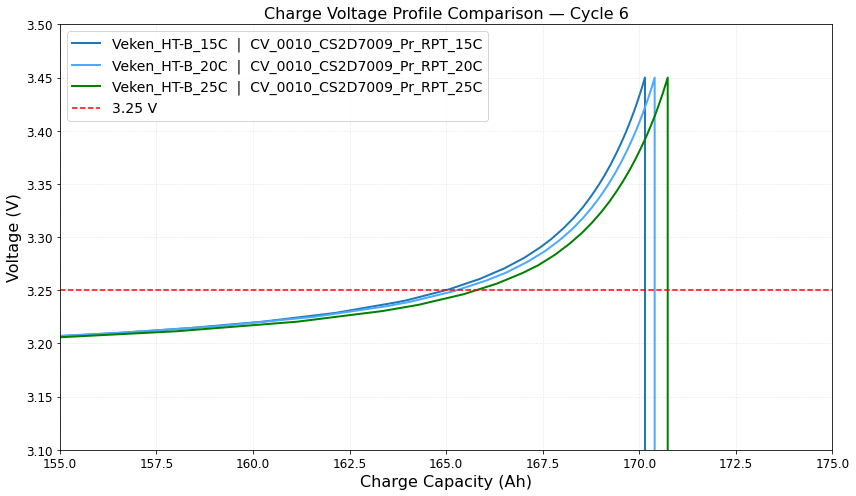

In [9]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

any_plotted = False
for cfg, tr, profile in zip(TEST_CONFIGS, test_records, charge_profiles):
    cap  = profile["capacity"]   # raw Ah, no normalization
    volt = profile["voltage"]
    if cap is None or len(cap) == 0:
        print(f"  ⚠  Skipping '{cfg['label']}' — no data to plot.")
        continue

    ax.plot(
        cap,
        volt,
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        linewidth=2,
        label=f"{cfg['label']}  |  {tr.name}",
    )
    any_plotted = True

if not any_plotted:
    print("No data available to plot. Check your test names and cycle number.")
else:
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xlabel("Charge Capacity (Ah)", fontsize=16)
    ax.set_ylabel("Voltage (V)", fontsize=16)
    ax.set_title(
        f"Charge Voltage Profile Comparison — Cycle {CYCLE_TO_PLOT}",
        fontsize=16,
    )
    
    ax.axhline(y=3.25, color="red", linestyle="--", linewidth=1.5, label="3.25 V")
    
    ax.legend(fontsize=14, loc="best")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    #plt.savefig(OUTPUT_FILENAME, dpi=300)
    plt.show()

In [10]:
import pandas as pd

OUTPUT_EXCEL = "charge_voltage_profiles_cycle_ColdTChar_Camp3_1.8V-LCV.xlsx".format(CYCLE_TO_PLOT)

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    for cfg, tr, profile in zip(TEST_CONFIGS, test_records, charge_profiles):
        cap  = profile["capacity"]
        volt = profile["voltage"]
        if cap is None or len(cap) == 0:
            print(f"  ⚠  Skipping '{cfg['label']}' — no data.")
            continue

        df = pd.DataFrame({
            "Charge Capacity (Ah)": cap,
            "Voltage (V)":          volt,
        })

        # Sheet names max 31 chars
        sheet_name = cfg["label"][:31]
        df.to_excel(writer, sheet_name=sheet_name, index=False)
        print(f"  ✔  Written sheet: {sheet_name}  ({len(df)} rows)")

print(f"\n✔  Saved to '{OUTPUT_EXCEL}'")

  ✔  Written sheet: Veken_HT-B_15C  (426 rows)
  ✔  Written sheet: Veken_HT-B_20C  (391 rows)
  ✔  Written sheet: Veken_HT-B_25C  (502 rows)

✔  Saved to 'charge_voltage_profiles_cycle_ColdTChar_Camp3_1.8V-LCV.xlsx'
